# Fase 2 — Comprensión de los datos: dataset de Clientes

**TPI Ciencia de Datos — DS Airlines**

Análisis exploratorio del dataset `Clientes.xlsx` (50.000 clientes, 14 variables). El objetivo es entender cómo se relacionan las variables entre sí para decidir cuáles entran a la vista minable de los modelos de segmentación.

**Contenido:**

1. Carga del dataset y definición de variables numéricas y categóricas.
2. Matriz de dispersión de las variables numéricas.
3. Correlaciones de Pearson (dataset completo y solo afiliados al programa de millas).
4. Asociación entre variables categóricas (V de Cramer).
5. Relación numérica–categórica (ANOVA de un factor y boxplots).
6. Conclusiones para la fase de Preparación.

## 1. Carga del dataset y definición de variables

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

# Subí Clientes.xlsx al panel de archivos de Colab (o dejalo en la misma carpeta que el notebook)
df = pd.read_excel('Clientes.xlsx')

numericas = ['edad', 'cant_vuelos', 'gasto_acumulado', 'gasto_acumulado_extra',
             'cantidad_millas', 'ingreso_mensual', 'anticipacion_compra_promedio']
categoricas = ['sexo', 'provincia', 'ocupacion', 'clase_preferida',
               'programaMillas', 'canal_compra']

print(df.shape)
df.head()

(50000, 14)


,id_cliente,sexo,provincia,edad,ocupacion,cant_vuelos,clase_preferida,gasto_acumulado,gasto_acumulado_extra,programaMillas,cantidad_millas,ingreso_mensual,anticipacion_compra_promedio,canal_compra
0,1,M,Salta,24,Comerciante,21,Económica,5731.62,1222.62,Sí,19113,1367,3,Agencia
1,2,F,Córdoba,49,Médico,16,Económica,2593.40,510.70,No,0,6252,30,App
2,3,M,Buenos Aires,41,Docente,10,Económica,2850.62,627.01,No,0,1593,16,App
3,4,F,São Paulo,19,Empleado,9,Económica,2749.41,540.22,No,0,862,47,Agencia
4,5,M,Rio Grande do Sul,31,Profesional independiente,16,Económica,5751.04,817.55,No,0,2927,26,Web


## 2. Matriz de dispersión de las variables numéricas

Se grafica una muestra aleatoria de 15.000 clientes (semilla 42), porque con los 50.000 puntos el gráfico queda saturado.

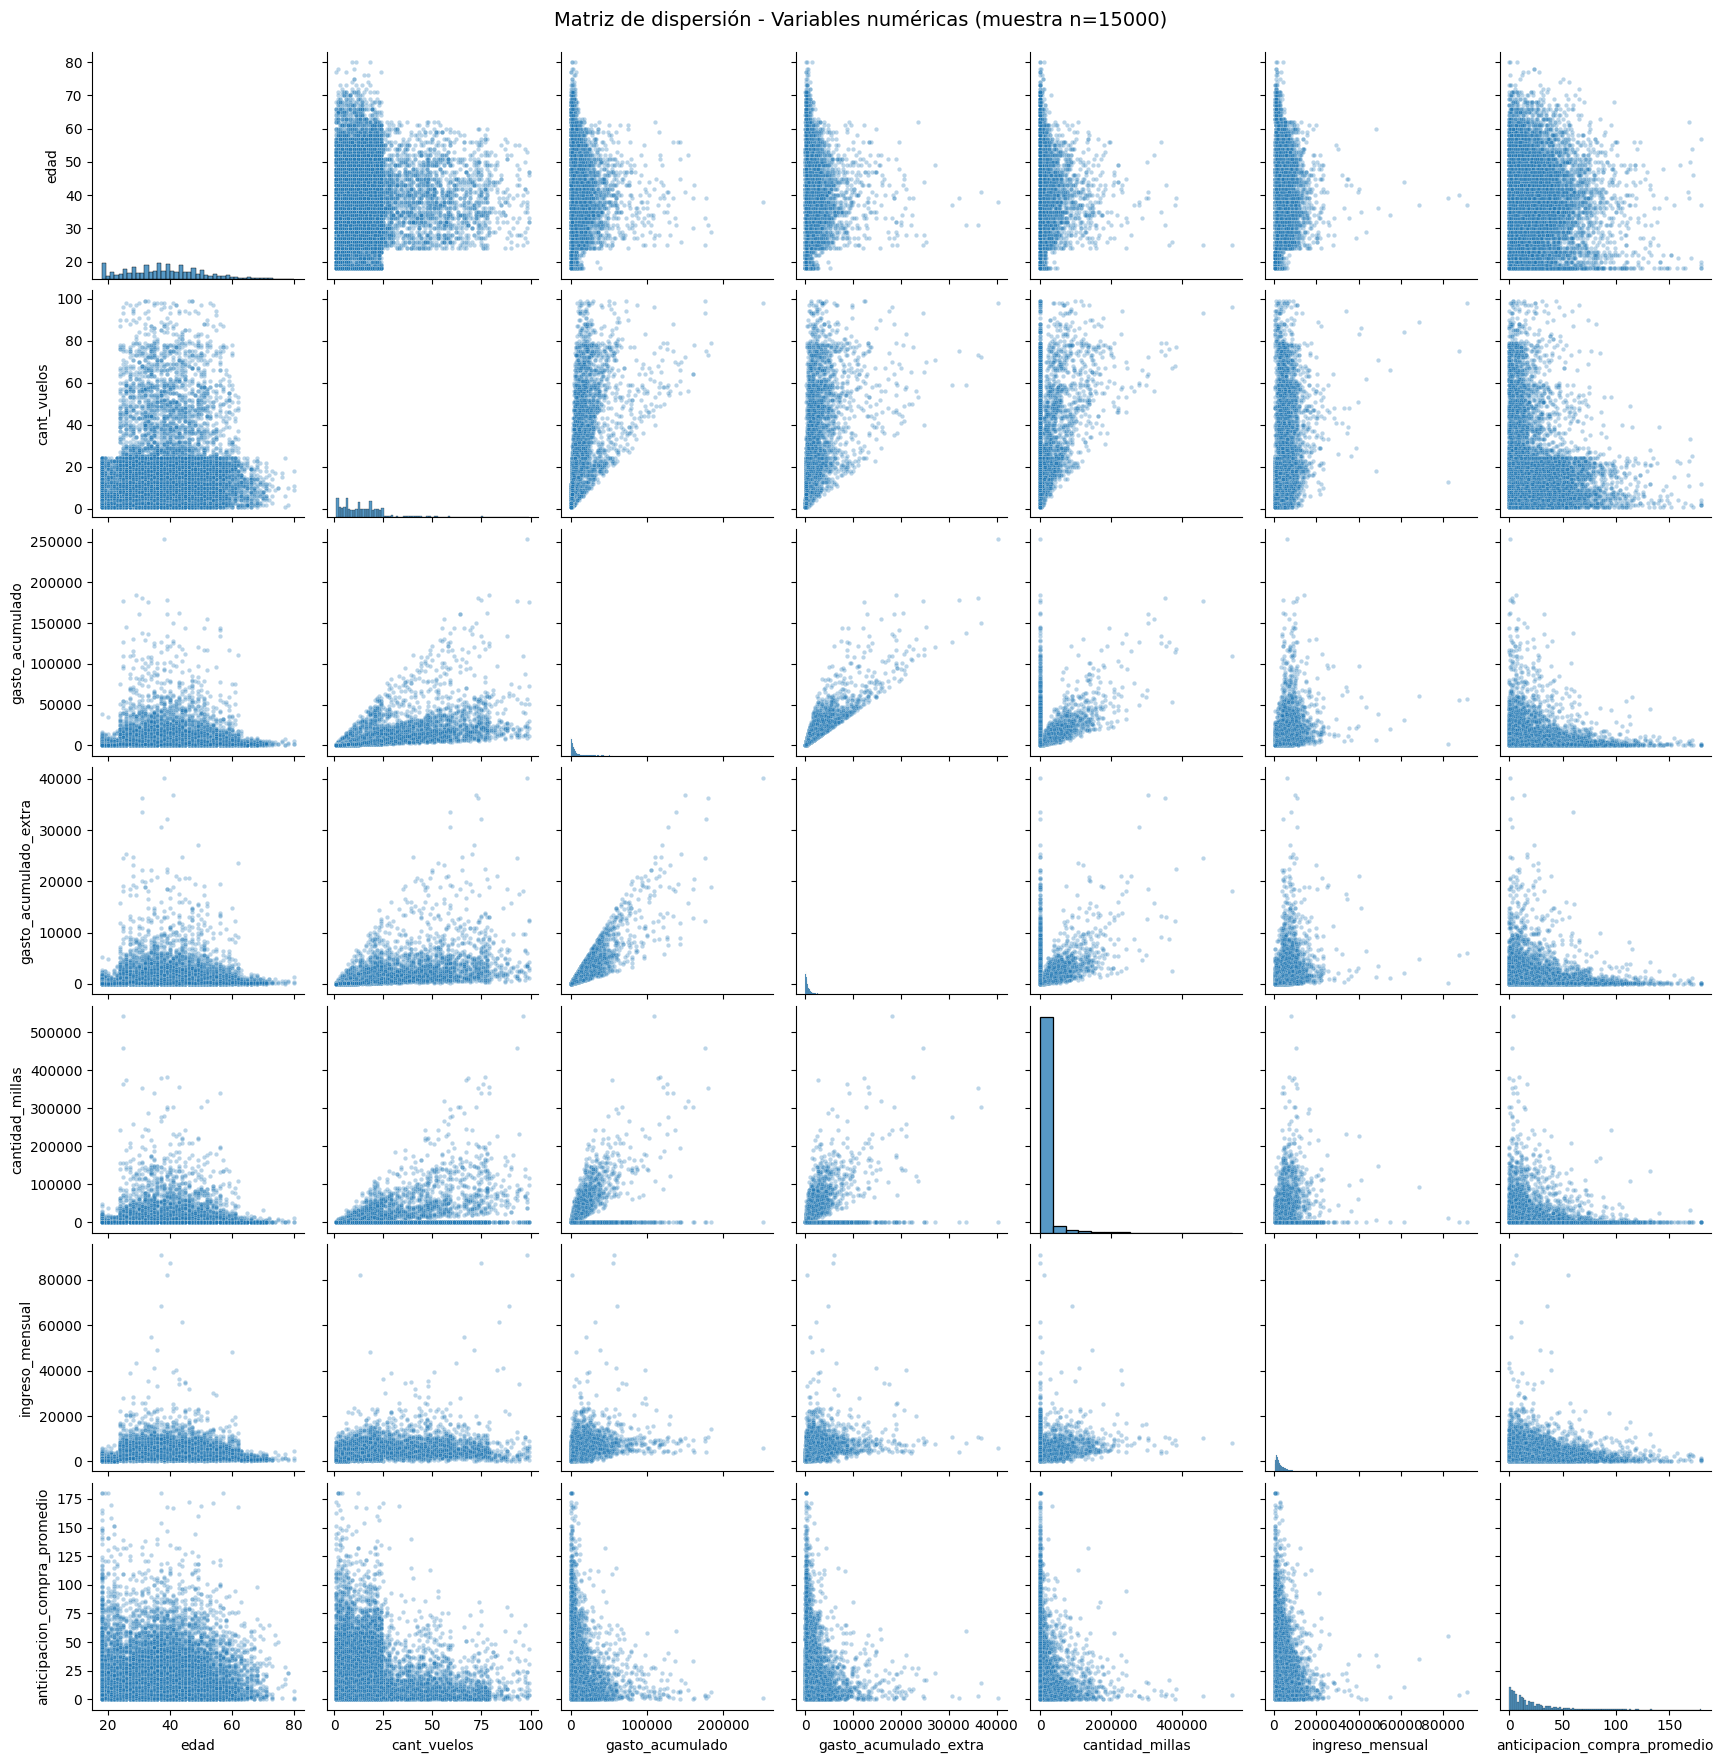

In [ ]:
# Muestra aleatoria para que sea legible (50k puntos saturan el gráfico)
muestra = df[numericas].sample(n=15000, random_state=42)

sns.pairplot(muestra, diag_kind='hist', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Matriz de dispersión - Variables numéricas (muestra n=15000)',
             y=1.01, fontsize=14)
plt.show()

## 3. Correlaciones entre variables numéricas

Matriz de correlación de Pearson con sus p-valores. Interesa detectar pares redundantes que deban eliminarse antes del modelado.

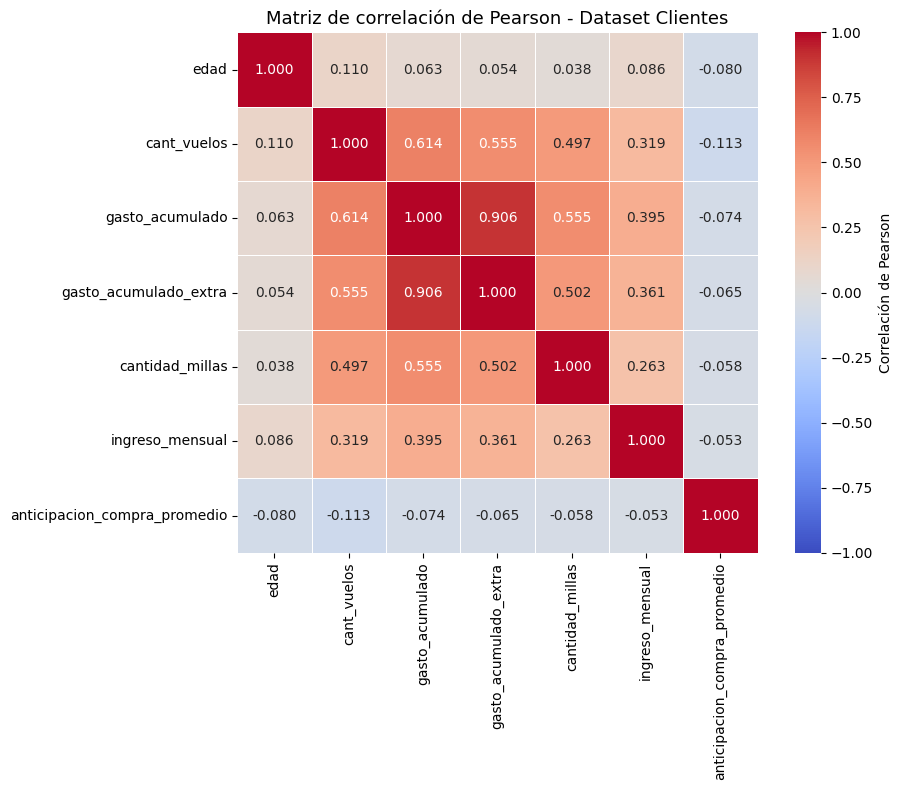


Matriz de correlaciones:
                               edad  cant_vuelos  gasto_acumulado  \
edad                          1.000        0.110            0.063   
cant_vuelos                   0.110        1.000            0.614   
gasto_acumulado               0.063        0.614            1.000   
gasto_acumulado_extra         0.054        0.555            0.906   
cantidad_millas               0.038        0.497            0.555   
ingreso_mensual               0.086        0.319            0.395   
anticipacion_compra_promedio -0.080       -0.113           -0.074   

                              gasto_acumulado_extra  cantidad_millas  \
edad                                          0.054            0.038   
cant_vuelos                                   0.555            0.497   
gasto_acumulado                               0.906            0.555   
gasto_acumulado_extra                         1.000            0.502   
cantidad_millas                               0.502          

In [ ]:
# Matriz de correlaciones
corr = df[numericas].corr(method='pearson')

# Matriz de p-valores
pvals = pd.DataFrame(np.zeros_like(corr), columns=corr.columns, index=corr.index)
for i in numericas:
    for j in numericas:
        if i != j:
            _, p = stats.pearsonr(df[i], df[j])
            pvals.loc[i, j] = p

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación de Pearson - Dataset Clientes', fontsize=13)
plt.tight_layout()
plt.show()

print("\nMatriz de correlaciones:")
print(corr.round(3))
print("\nMatriz de p-valores:")
print(pvals.round(4))

### 3.1. Correlaciones entre los afiliados al programa de millas

Los clientes no afiliados tienen `cantidad_millas = 0`, lo que puede distorsionar las correlaciones de esa variable. Se repite el análisis solo sobre los afiliados.

Afiliados al programa: 11948 (23.9%)


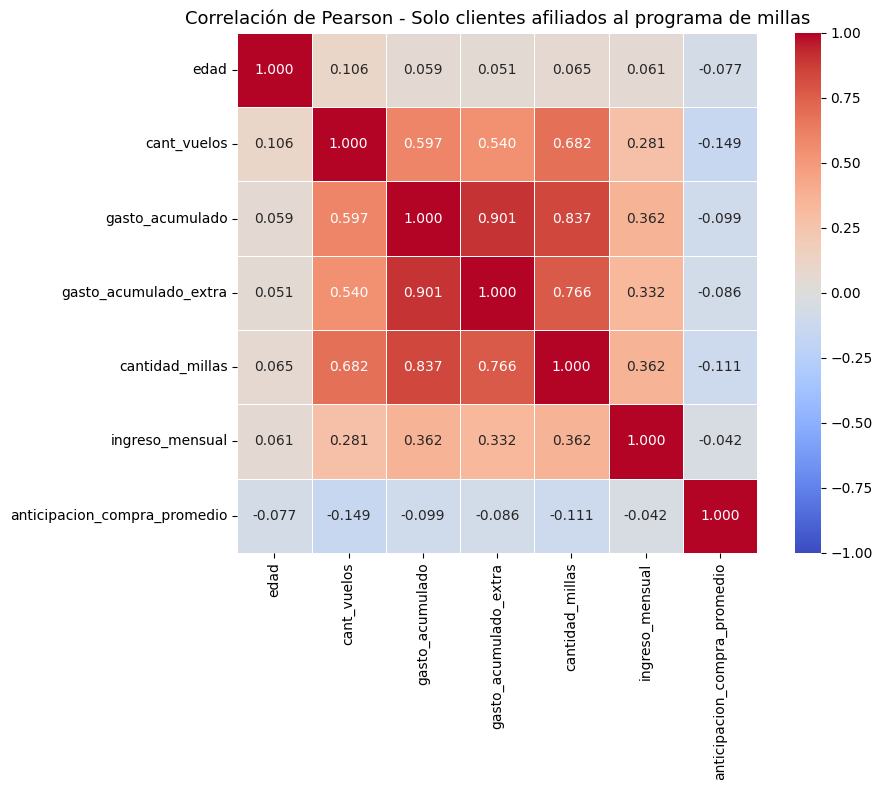

In [ ]:
afiliados = df[df['programaMillas'] == 'Sí']
print(f"Afiliados al programa: {len(afiliados)} ({len(afiliados)/len(df)*100:.1f}%)")

corr_afiliados = afiliados[numericas].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_afiliados, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlación de Pearson - Solo clientes afiliados al programa de millas',
          fontsize=13)
plt.tight_layout()
plt.show()

## 4. Asociación entre variables categóricas

Se calcula la **V de Cramer** (a partir del Chi-cuadrado) para cada par de variables categóricas. Valores cercanos a 0 indican independencia y cercanos a 1, asociación fuerte.

Asociación entre variables categóricas:
          Var 1           Var 2  V de Cramer  p-valor
      ocupacion clase_preferida        0.278   0.0000
      ocupacion  programaMillas        0.240   0.0000
      ocupacion    canal_compra        0.068   0.0000
clase_preferida  programaMillas        0.066   0.0000
      provincia clase_preferida        0.028   0.0808
      provincia       ocupacion        0.025   0.2732
      provincia  programaMillas        0.024   0.5244
      provincia    canal_compra        0.024   0.6085
           sexo       provincia        0.021   0.9410
           sexo       ocupacion        0.013   0.9678
clase_preferida    canal_compra        0.011   0.0863
           sexo    canal_compra        0.010   0.1040
 programaMillas    canal_compra        0.010   0.1688
           sexo  programaMillas        0.008   0.2345
           sexo clase_preferida        0.008   0.2288


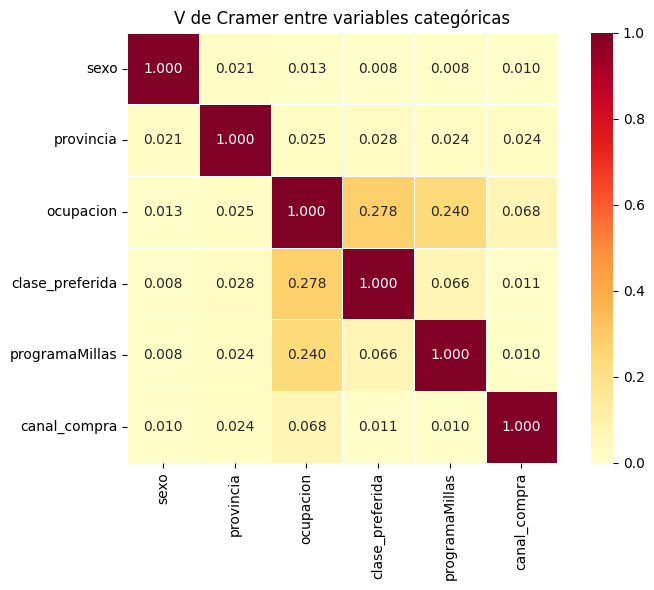

In [ ]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))), p

# Tabla resumen V de Cramer + p-valor entre todos los pares
resultados = []
for i, c1 in enumerate(categoricas):
    for c2 in categoricas[i+1:]:
        v, p = cramers_v(df[c1], df[c2])
        resultados.append({'Var 1': c1, 'Var 2': c2,
                           'V de Cramer': round(v, 3),
                           'p-valor': round(p, 4)})

resumen_cat = pd.DataFrame(resultados).sort_values('V de Cramer', ascending=False)
print("Asociación entre variables categóricas:")
print(resumen_cat.to_string(index=False))

# Heatmap para visualizar
matriz_v = pd.DataFrame(np.eye(len(categoricas)),
                        index=categoricas, columns=categoricas)
for r in resultados:
    matriz_v.loc[r['Var 1'], r['Var 2']] = r['V de Cramer']
    matriz_v.loc[r['Var 2'], r['Var 1']] = r['V de Cramer']

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_v, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title('V de Cramer entre variables categóricas')
plt.tight_layout()
plt.show()

## 5. Relación entre variables numéricas y categóricas

ANOVA de un factor de cada variable numérica contra cada categórica (`provincia` se omite por tener 31 categorías), con boxplots de las relaciones más marcadas.

ANOVA de un factor (numérica ~ categórica):


--- sexo ---
  edad                                F=    0.10  p=0.9051  ns
  cant_vuelos                         F=    0.86  p=0.4225  ns
  gasto_acumulado                     F=    1.14  p=0.3205  ns
  gasto_acumulado_extra               F=    1.54  p=0.2143  ns
  cantidad_millas                     F=    7.60  p=0.0005  ***
  ingreso_mensual                     F=    2.23  p=0.1078  ns
  anticipacion_compra_promedio        F=    0.10  p=0.9037  ns

--- ocupacion ---
  edad                                F= 1292.37  p=0.0000  ***
  cant_vuelos                         F= 6443.96  p=0.0000  ***
  gasto_acumulado                     F= 1542.92  p=0.0000  ***
  gasto_acumulado_extra               F= 1163.66  p=0.0000  ***
  cantidad_millas                     F=  900.68  p=0.0000  ***
  ingreso_mensual                     F= 1418.03  p=0.0000  ***
  anticipacion_compra_promedio        F=  188.03  p=0.0000  ***

--- clase_preferida ---
  edad 

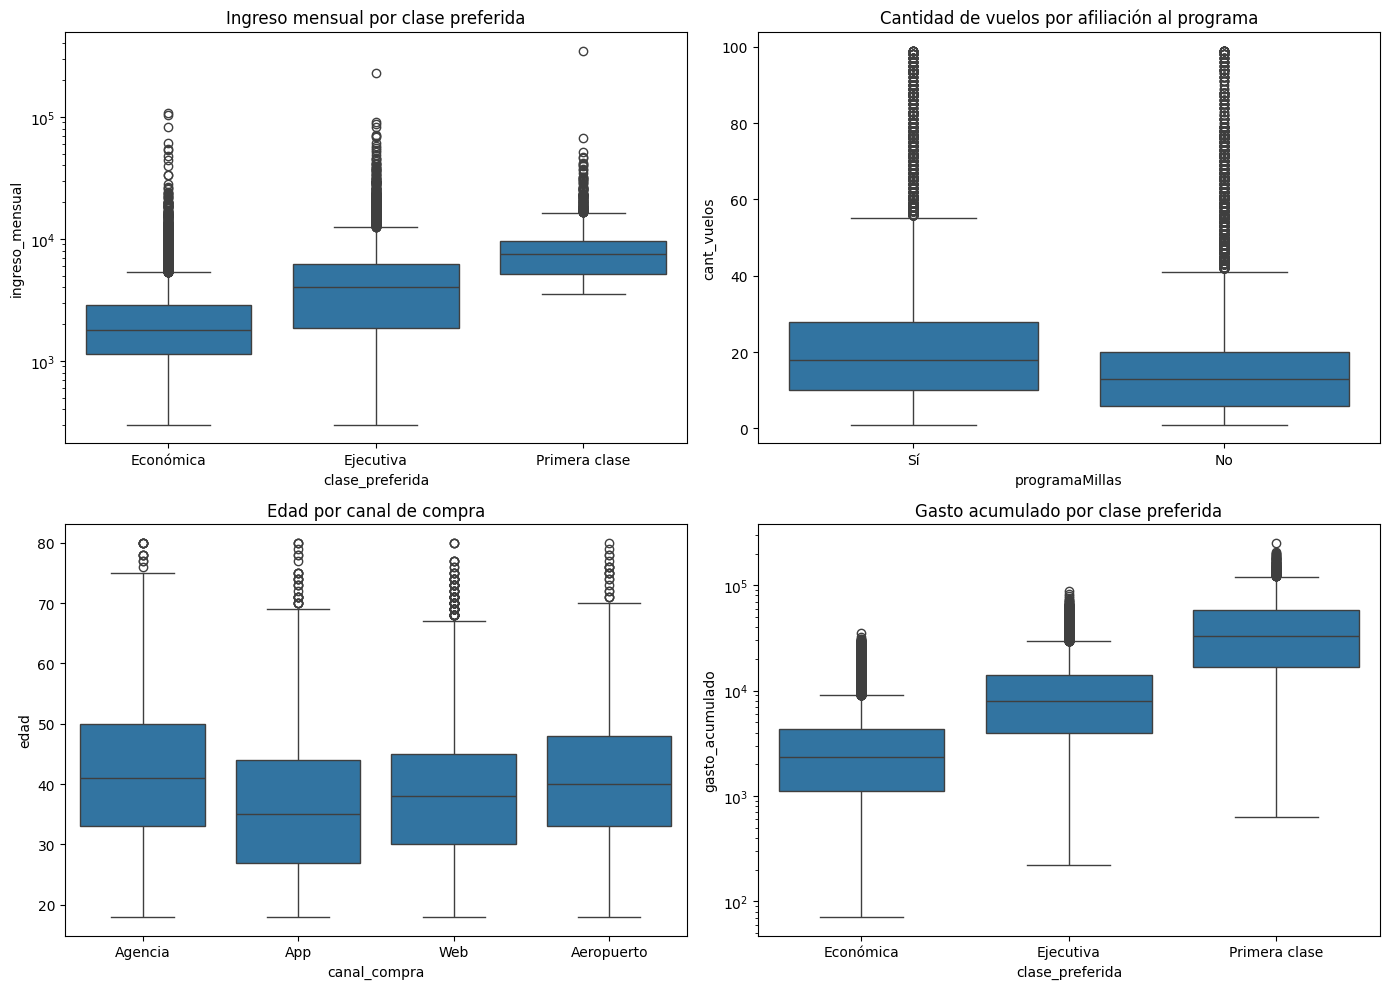

In [ ]:
# Comparación de medias por categoría con ANOVA
print("ANOVA de un factor (numérica ~ categórica):\n")
for cat in categoricas:
    if df[cat].nunique() > 30:  # provincia tiene 31 categorías, la salteo
        continue
    print(f"\n--- {cat} ---")
    for num in numericas:
        grupos = [df[df[cat] == g][num].values for g in df[cat].unique()]
        f, p = f_oneway(*grupos)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {num:35s} F={f:8.2f}  p={p:.4f}  {sig}")

# Boxplots visuales para las relaciones más fuertes (ajustá según los resultados)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df, x='clase_preferida', y='ingreso_mensual', ax=axes[0,0])
axes[0,0].set_title('Ingreso mensual por clase preferida')
axes[0,0].set_yscale('log')

sns.boxplot(data=df, x='programaMillas', y='cant_vuelos', ax=axes[0,1])
axes[0,1].set_title('Cantidad de vuelos por afiliación al programa')

sns.boxplot(data=df, x='canal_compra', y='edad', ax=axes[1,0])
axes[1,0].set_title('Edad por canal de compra')

sns.boxplot(data=df, x='clase_preferida', y='gasto_acumulado', ax=axes[1,1])
axes[1,1].set_title('Gasto acumulado por clase preferida')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

## 6. Conclusiones para la fase de Preparación

- **`gasto_acumulado_extra` es redundante** con `gasto_acumulado` (r = 0,906), así que se elimina de la vista minable.
- **`provincia` no se asocia con ninguna otra variable**: todas sus V de Cramer son menores a 0,03 y ninguna es significativa. Se excluye.
- **`sexo` tampoco aporta**: su asociación con las categóricas es prácticamente nula y en los ANOVA solo muestra una diferencia significativa, y pequeña, en `cantidad_millas`. Se excluye.
- **`ocupacion`, `clase_preferida`, `programaMillas` y `canal_compra`** sí discriminan: tienen F muy altos contra las variables numéricas y se asocian entre sí. Como los algoritmos de clustering trabajan con distancias euclídeas, no entran al modelo, pero se usan para interpretar los clusters.
- Las seis numéricas que quedan (`edad`, `cant_vuelos`, `cantidad_millas`, `ingreso_mensual`, `anticipacion_compra_promedio` y `gasto_acumulado`) forman la vista minable, estandarizadas con z-score.